In [5]:
import sys
!{sys.executable} -m pip install pandas

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -------------------------------- ------- 8.1/9.9 MB 39.0 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 34.4 MB/s  0:00:00
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ------------------------- -------------- 7.9/12.6 MB 39.0 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 35.2 MB/s  0:00:00

   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [8]:
import pandas as pd

print("Fetching data from Our World in Data...")
owid_url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
raw_df = pd.read_csv(owid_url)

# The target variables needed for economic decoupling & Kaya Identity analysis
keep_columns = [
    'country', 'year', 'iso_code', 
    'population', 'gdp',                        # Demographics & Economy
    'co2', 'consumption_co2',                   # Territorial vs. Trade-adjusted Carbon
    'primary_energy_consumption',                # Total Energy Used (E)
    'energy_per_gdp',                           # Energy Intensity (E/GDP)
    'energy_per_capita'                         # Energy per person
]

df = raw_df[keep_columns].copy()

# Filter for recent history and drop rows where critical mapping data (like GDP or CO2) is missing
df = df[df['year'] >= 1965].dropna(subset=['gdp', 'co2', 'primary_energy_consumption'])

print(f"Data successfully loaded! Final shape: {df.shape}")
df.head()

Fetching data from Our World in Data...
Data successfully loaded! Final shape: (7776, 10)


,country,year,iso_code,population,gdp,co2,consumption_co2,primary_energy_consumption,energy_per_gdp,energy_per_capita
230,Afghanistan,1980,AFG,13169313.0,1.532984e+10,1.756,NaN,6.337,0.413,481.209
231,Afghanistan,1981,AFG,11937586.0,1.564534e+10,1.978,NaN,7.290,0.466,610.639
232,Afghanistan,1982,AFG,10991380.0,1.598041e+10,2.095,NaN,7.889,0.494,717.766
233,Afghanistan,1983,AFG,10917985.0,1.675533e+10,2.520,NaN,9.882,0.590,905.127
234,Afghanistan,1984,AFG,11190222.0,1.707215e+10,2.822,NaN,9.930,0.582,887.371


In [12]:
# 1. Calculate Affluence (GDP per Capita)
df['gdp_per_capita'] = df['gdp'] / df['population']

# 2. Calculate Carbon Intensity of Energy (CO2 / Energy)
# We add a tiny offset (1e-9) just to prevent any accidental division-by-zero errors
df['carbon_intensity_of_energy'] = df['co2'] / (df['primary_energy_consumption'] + 1e-9)

# Preview our fresh climate economics metrics
df[['country', 'year', 'gdp_per_capita', 'energy_per_gdp', 'carbon_intensity_of_energy']].head()

,country,year,gdp_per_capita,energy_per_gdp,carbon_intensity_of_energy
230,Afghanistan,1980,1164.057381,0.413,0.277103
231,Afghanistan,1981,1310.595291,0.466,0.271331
232,Afghanistan,1982,1453.903877,0.494,0.265560
233,Afghanistan,1983,1534.654334,0.590,0.255009
234,Afghanistan,1984,1525.631306,0.582,0.284189


In [13]:
# Filter the dataframe for the UK to see their data over time
uk_df = df[df['country'] == 'United Kingdom']

# Let's see the most recent 10 rows of data they have available
uk_df[['country', 'year', 'gdp', 'co2', 'gdp_per_capita', 'carbon_intensity_of_energy']].tail(10)

,country,year,gdp,co2,gdp_per_capita,carbon_intensity_of_energy
47771,United Kingdom,2013,2.296253e+12,477.611,35661.973846,0.199965
47772,United Kingdom,2014,2.369726e+12,438.807,36532.678063,0.194532
47773,United Kingdom,2015,2.426436e+12,422.461,37111.619380,0.185333
47774,United Kingdom,2016,2.478973e+12,399.430,37620.984186,0.177768
47775,United Kingdom,2017,2.539549e+12,387.367,38272.454427,0.172083
47776,United Kingdom,2018,2.582848e+12,379.730,38692.921106,0.169038
47777,United Kingdom,2019,2.624285e+12,364.753,39103.674793,0.166327
47778,United Kingdom,2020,2.334804e+12,326.263,34665.769583,0.164543
47779,United Kingdom,2021,2.512190e+12,342.366,37124.798187,0.171960
47780,United Kingdom,2022,2.615231e+12,311.118,38358.124233,0.154789


In [11]:
import sys
!{sys.executable} -m pip install matplotlib

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------- ----- 8.1/9.5 MB 39.0 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 33.2 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 28.2 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------  7.1/7.2 MB 38.9 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 32.9 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


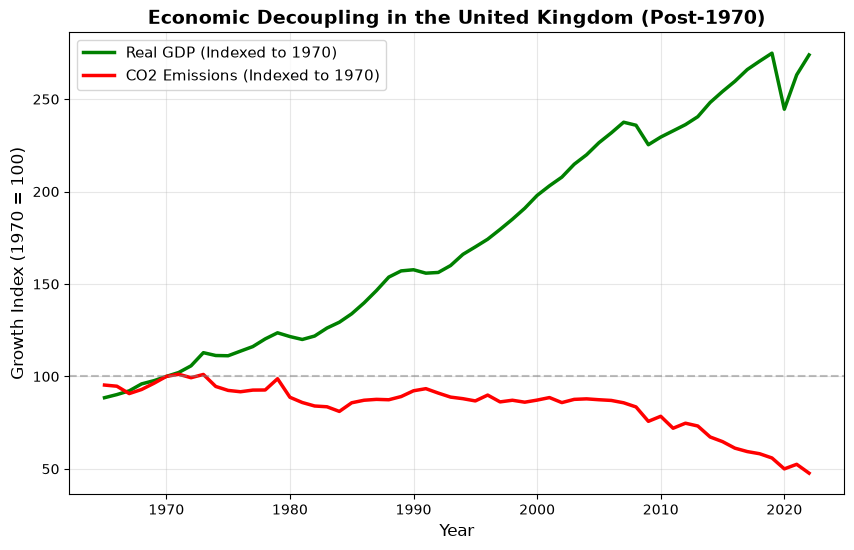

In [14]:
import matplotlib.pyplot as plt

# 1. Filter the dataset for the United Kingdom
country_name = 'United Kingdom'
plot_df = df[df['country'] == country_name].copy()

# 2. Index the data to a base year (1970) so we can see % change over time
base_year = 1970
base_data = plot_df[plot_df['year'] == base_year].iloc[0]

plot_df['GDP_indexed'] = (plot_df['gdp'] / base_data['gdp']) * 100
plot_df['CO2_indexed'] = (plot_df['co2'] / base_data['co2']) * 100

# 3. Build the chart
plt.figure(figsize=(10, 6))
plt.plot(plot_df['year'], plot_df['GDP_indexed'], label='Real GDP (Indexed to 1970)', color='green', linewidth=2.5)
plt.plot(plot_df['year'], plot_df['CO2_indexed'], label='CO2 Emissions (Indexed to 1970)', color='red', linewidth=2.5)
plt.title(f'Economic Decoupling in the {country_name} (Post-1970)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Growth Index (1970 = 100)', fontsize=12)
plt.axhline(100, color='gray', linestyle='--', alpha=0.5) # Baseline marker
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Display chart
plt.show()